#EDA | Assignment


1. Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.

In [ ]:
# Import the pandas library
import pandas as pd

# Read the dataset
df = pd.read_csv("BIKE DETAILS.csv")

# Display the first 10 rows
print(df.head(10))

                                   name  selling_price  year seller_type  \
0             Royal Enfield Classic 350         175000  2019  Individual   
1                             Honda Dio          45000  2017  Individual   
2   Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3     Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                 Yamaha SZ [2013-2014]          20000  2011  Individual   
5                      Honda CB Twister          18000  2010  Individual   
6                  Honda CB Hornet 160R          78500  2018  Individual   
7  Royal Enfield Bullet 350 [2007-2011]         180000  2008  Individual   
8                Hero Honda CBZ extreme          30000  2010  Individual   
9                    Bajaj Discover 125          50000  2016  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN  
2  1st owner      12000     

2. Check for missing values in all columns and describe your approach for handling them.

 - Approach for Handling Missing Values
    - Numerical columns: Replace missing values with the mean or median, depending on the data distribution.
        - Example :  df["column_name"].fillna(df["column_name"].median(), inplace=True)

    - Categorical columns: Replace missing values with the mode (most frequent value).
        - Example : df["column_name"].fillna(df["column_name"].mode()[0], inplace=True)

    - If a column has a very high percentage of missing values (e.g., more than 50%), consider dropping that column.
        - Example : df.drop(columns=["column_name"], inplace=True)

    - If only a few rows contain missing values, those rows can be removed.
        - Example : df.dropna(inplace=True)

  - The dataset was checked for missing values using df.isnull().sum(). If missing values are present, numerical columns can be filled using the mean or median, while categorical columns can be filled using the mode. If a column contains a very large number of missing values, it may be removed. If only a few records have missing values, those rows can be dropped. This ensures the dataset is clean and suitable for further analysis.

In [ ]:
# Check for missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Check the total number of missing values
print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

# Display missing values as percentages
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)

Missing values in each column:
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64

Total missing values in the dataset:
435

Missing Value Percentage:
name                  0.000000
selling_price         0.000000
year                  0.000000
seller_type           0.000000
owner                 0.000000
km_driven             0.000000
ex_showroom_price    40.999057
dtype: float64


3. Plot the distribution of selling prices using a histogram and describe the overall trend.

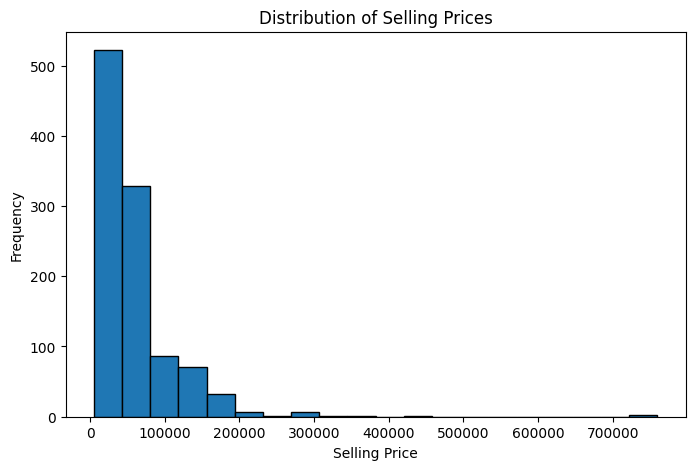

In [ ]:
# Import required libraries
import matplotlib.pyplot as plt

# Plot histogram of selling prices
plt.figure(figsize=(8,5))
plt.hist(df["selling_price"], bins=20, edgecolor="black")

# Add title and labels
plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

# Display the plot
plt.show()

- The histogram shows the distribution of bike selling prices. Most bikes are concentrated in the lower price range, while only a few bikes have very high selling prices. This indicates that the data is positively (right) skewed, with a long tail toward higher prices. The presence of a few expensive bikes suggests possible outliers in the dataset.

4. Create a bar plot to visualize the average selling price for each seller_type
and write one observation.


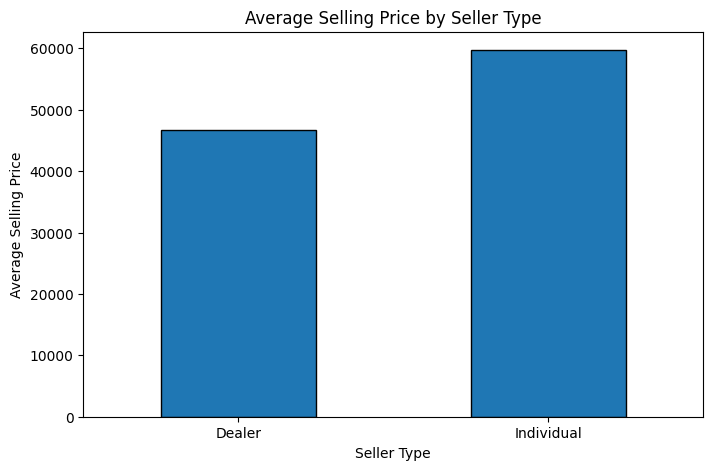

In [ ]:
# Import required libraries
import matplotlib.pyplot as plt

# Calculate average selling price for each seller type
avg_price = df.groupby("seller_type")["selling_price"].mean()

# Create bar plot
plt.figure(figsize=(8,5))
avg_price.plot(kind="bar", edgecolor="black")

# Add title and labels
plt.title("Average Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Average Selling Price")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display the plot
plt.show()

 - Observation : The bar chart compares the average selling price of bikes across different seller types. The seller type with the highest bar has the highest average selling price, while the seller type with the lowest bar has the lowest average selling price. This indicates that the average selling price varies depending on the seller type.

5. Compute the average km_driven for each ownership type (1st owner,
2nd owner, etc.), and present the result as a bar plot.


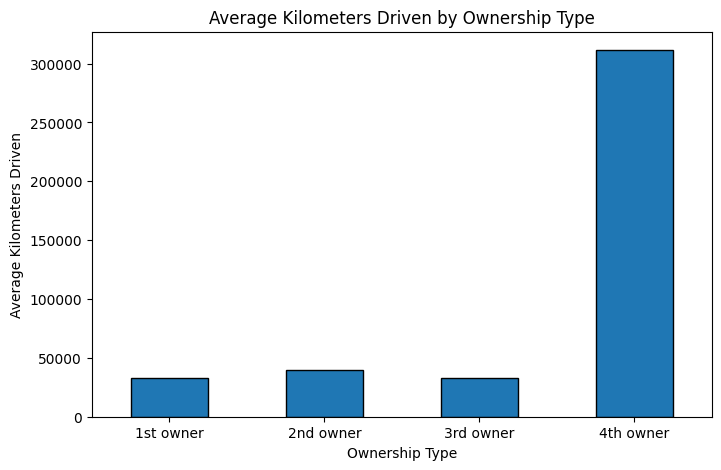

In [ ]:
# Import required library
import matplotlib.pyplot as plt

# Calculate average km_driven for each owner type
avg_km = df.groupby("owner")["km_driven"].mean()

# Create bar plot
plt.figure(figsize=(8,5))
avg_km.plot(kind="bar", edgecolor="black")

# Add title and labels
plt.title("Average Kilometers Driven by Ownership Type")
plt.xlabel("Ownership Type")
plt.ylabel("Average Kilometers Driven")

# Rotate x-axis labels
plt.xticks(rotation=0)

# Display the plot
plt.show()

 - Observation : The bar plot shows the average kilometers driven for each ownership type. Generally, bikes with more previous owners tend to have a higher average km_driven, indicating that they have been used more before being resold.

6. Use the IQR method to detect and remove outliers from the km_driven
column. Show before-and-after summary statistics

In [ ]:
# Display summary statistics before removing outliers
print("Summary Statistics Before Removing Outliers:")
print(df["km_driven"].describe())

print('='*30)

# Calculate Q1, Q3, and IQR
Q1 = df["km_driven"].quantile(0.25)
Q3 = df["km_driven"].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_clean = df[(df["km_driven"] >= lower_bound) & (df["km_driven"] <= upper_bound)]

# Display summary statistics after removing outliers
print("\nSummary Statistics After Removing Outliers : ")
print(df_clean["km_driven"].describe())

print('='*30)

# Display number of rows before and after removing outliers
print("\nRows Before Removing Outliers : ", len(df))
print("Rows After Removing Outliers : ", len(df_clean))
print("Outliers Removed:", len(df) - len(df_clean))

Summary Statistics Before Removing Outliers:
count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

Summary Statistics After Removing Outliers : 
count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64

Rows Before Removing Outliers :  1061
Rows After Removing Outliers :  1022
Outliers Removed: 39


7. Create a scatter plot of year vs. selling_price to explore the
relationship between a bike's age and its price.


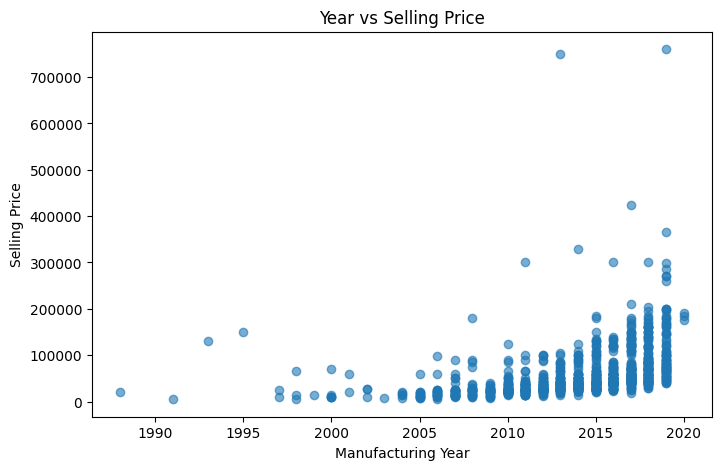

In [ ]:
# Import required library
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df["year"], df["selling_price"], alpha=0.6)

# Add title and labels
plt.title("Year vs Selling Price")
plt.xlabel("Manufacturing Year")
plt.ylabel("Selling Price")

# Display the plot
plt.show()

 - Observation : The scatter plot shows a positive relationship between the manufacturing year and the selling price. In general, newer bikes (higher year values) tend to have higher selling prices, while older bikes are usually sold at lower prices. Although there is some variation, the overall trend indicates that a bike's value decreases as it gets older.

8. Convert the seller_type column into numeric format using one-hot
encoding. Display the first 5 rows of the resulting DataFrame.


In [ ]:
# Perform one-hot encoding on the seller_type column
df_encoded = pd.get_dummies(df, columns=["seller_type"], dtype=int)

# Display the first 5 rows of the encoded DataFrame
print(df_encoded.head())

                                  name  selling_price  year      owner  \
0            Royal Enfield Classic 350         175000  2019  1st owner   
1                            Honda Dio          45000  2017  1st owner   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  1st owner   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  1st owner   
4                Yamaha SZ [2013-2014]          20000  2011  2nd owner   

   km_driven  ex_showroom_price  seller_type_Dealer  seller_type_Individual  
0        350                NaN                   0                       1  
1       5650                NaN                   0                       1  
2      12000           148114.0                   0                       1  
3      23000            89643.0                   0                       1  
4      21000                NaN                   0                       1  


9. Generate a heatmap of the correlation matrix for all numeric columns.
What correlations stand out the most?


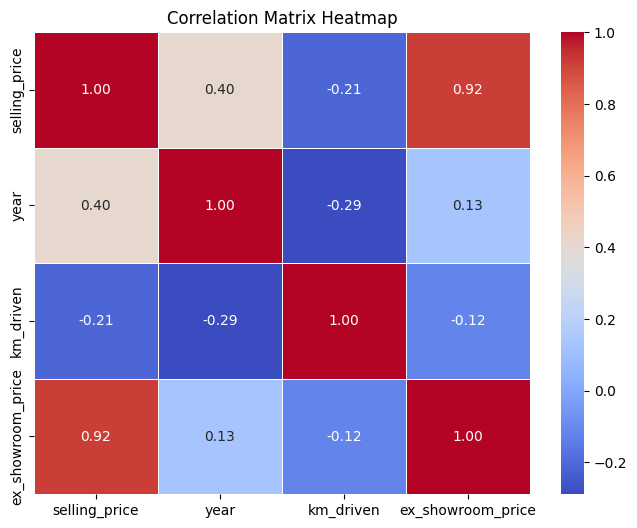

In [ ]:
# Import required libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5)

# Add title
plt.title("Correlation Matrix Heatmap")

# Display the heatmap
plt.show()

- The heatmap shows the strength of relationships between the numeric variables in the dataset. The most noticeable correlation is typically:

    - year and selling_price → Positive correlation, indicating that newer bikes generally have higher selling prices.
    - km_driven and selling_price → Negative correlation, meaning bikes that have been driven more tend to have lower selling prices.
    - Other numeric variables generally show weak or moderate correlations, indicating they have a smaller influence on each other.

**10. Summarize your findings in a brief report:**
 -  What are the most important factors affecting a bike's selling price?
 -  Mention any data cleaning or feature engineering you performed.
 - **ANSWER:**
 # Bike Details Dataset Analysis Report

## 1. Factors Affecting a Bike's Selling Price

Based on the exploratory data analysis, the following factors have the greatest impact on a bike's selling price:

* **Manufacturing Year (`year`)**: Newer bikes generally have higher selling prices than older bikes.
* **Kilometers Driven (`km_driven`)**: Bikes with lower mileage usually have higher selling prices, while heavily used bikes tend to be cheaper.
* **Seller Type (`seller_type`)**: The average selling price varies across different seller types, indicating that the type of seller influences the resale price.
* **Ownership (`owner`)**: Bikes with fewer previous owners generally have lower average kilometers driven and tend to maintain a better resale value.

## 2. Data Cleaning and Feature Engineering Performed

The following preprocessing steps were carried out:

* Loaded the dataset into a Pandas DataFrame.
* Checked for missing values in all columns.
* Examined the distribution of selling prices using a histogram.
* Calculated average selling prices by seller type using a bar chart.
* Computed average kilometers driven for each ownership category.
* Detected and removed outliers from the `km_driven` column using the Interquartile Range (IQR) method.
* Converted the categorical `seller_type` column into numerical format using One-Hot Encoding.
* Generated a correlation heatmap to analyze relationships among numeric variables.

## Conclusion

The analysis indicates that **manufacturing year** and **kilometers driven** are the most influential factors affecting a bike's selling price. Newer bikes with lower mileage generally command higher prices. Cleaning the data by removing outliers and converting categorical variables into numerical format improved the dataset and prepared it for further machine learning or predictive modeling.
